In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *
from xgboost import XGBClassifier, plot_importance

from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as Pipeline

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/drive/MyDrive/creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
print(f"Shape of the dataset: {df.shape}")
print(f"Total Entries: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Values: {df.duplicated().sum()}")
print(f"Legitimate Transactions: {df['Class'].value_counts()[0]}")
print(f"Fraudulent Transactions: {df['Class'].value_counts()[1]}")

Shape of the dataset: (284807, 31)
Total Entries: 284807
Total Features: 31
Missing Values: 0
Duplicate Values: 1081
Legitimate Transactions: 284315
Fraudulent Transactions: 492


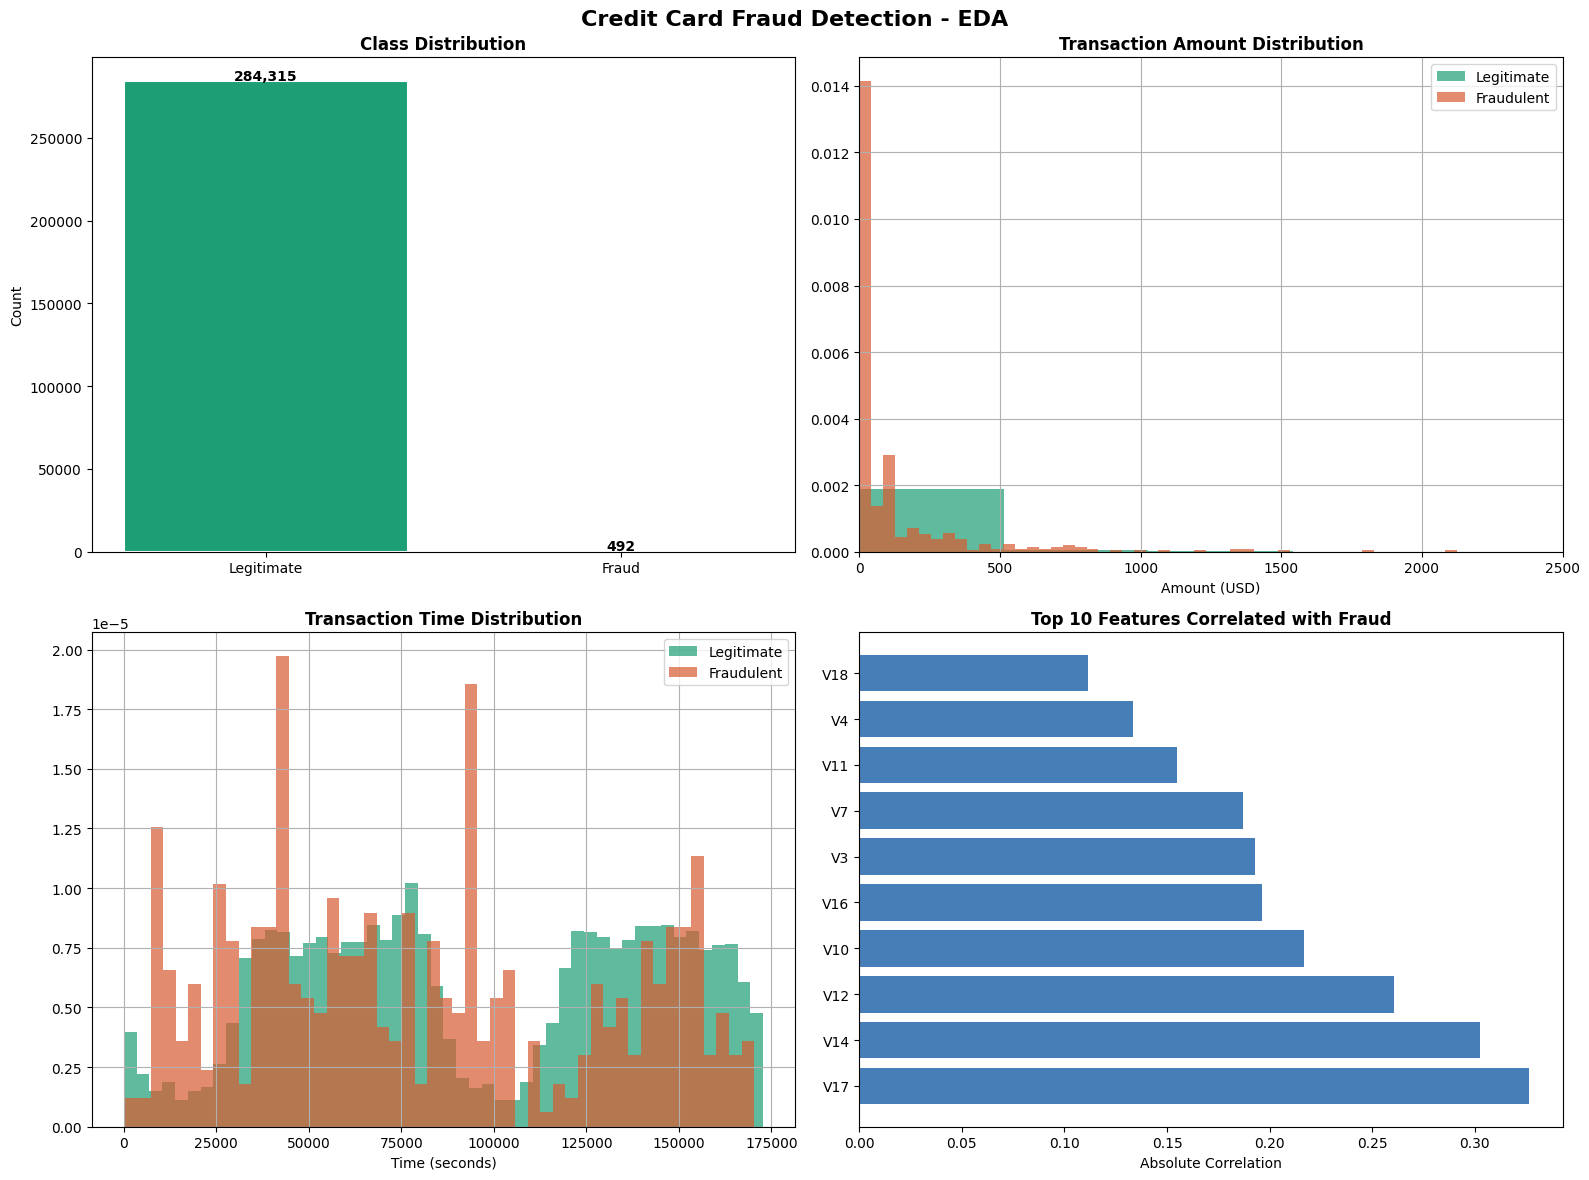

In [6]:
from tensorflow.python.ops.math_ops import lin_space
fig, axes = plt.subplots(2,2, figsize = (16,12))
fig.suptitle('Credit Card Fraud Detection - EDA', fontsize = 16, fontweight = 'bold')

class_counts = df['Class'].value_counts()
bars = axes[0,0].bar(['Legitimate','Fraud'], class_counts.values, color = ['#1D9E75','#D85A30'], edgecolor = 'white', linewidth = 1.5)
axes[0,0].set_title('Class Distribution', fontweight = 'bold')
axes[0,0].set_ylabel('Count')
for bar, val in zip(bars, class_counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'{val:,}', ha = 'center', fontweight = 'bold')

df[df['Class'] == 0]['Amount'].hist(ax = axes[0,1], bins = 50, alpha = 0.7, color = '#1D9E75', label = 'Legitimate', density = True)
df[df['Class'] == 1]['Amount'].hist(ax = axes[0,1], bins = 50, alpha = 0.7, color = '#D85A30', label = 'Fraudulent', density = True)
axes[0,1].set_title('Transaction Amount Distribution', fontweight = 'bold')
axes[0,1].set_xlabel('Amount (USD)')
axes[0,1].set_xlim(0, 2500)
axes[0,1].legend()

df[df['Class'] == 0]['Time'].hist(ax = axes[1,0], bins = 50, alpha = 0.7, color = '#1D9E75', label = 'Legitimate', density = True)
df[df['Class'] == 1]['Time'].hist(ax = axes[1,0], bins = 50, alpha = 0.7, color = '#D85A30', label = 'Fraudulent', density = True)
axes[1,0].set_title('Transaction Time Distribution', fontweight = 'bold')
axes[1,0].set_xlabel('Time (seconds)')
axes[1,0].legend()

correlations = df.corr()['Class'].drop('Class').abs().nlargest(10)
axes[1,1].barh(correlations.index, correlations.values, color = '#185FA5', alpha = 0.8)
axes[1,1].set_title('Top 10 Features Correlated with Fraud', fontweight = 'bold')
axes[1,1].set_xlabel('Absolute Correlation')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [7]:
X = df.drop('Class', axis = 1)
y = df['Class']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.15, random_state = 42, stratify = y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.2, random_state = 42, stratify = y_temp)

print(f"Training set: {len(X_train):>7,} samples | "f"Fraud: {y_train.sum():>4}")
print(f"Validation set: {len(X_val):>7,} samples | "f"Fraud: {y_val.sum():>4}")
print(f"Test set: {len(X_test):>7,} samples | "f"Fraud: {y_test.sum():>4}")

Training set: 193,668 samples | Fraud:  334
Validation set:  48,417 samples | Fraud:   84
Test set:  42,722 samples | Fraud:   74


In [8]:
xgb_pipeline = Pipeline(steps = [
    ('scalar', StandardScaler()),
    ('smote', SMOTE(random_state = 42, sampling_strategy= 0.1)),
    ('model', XGBClassifier(n_estimators = 300, max_depth = 6, learning_rate = 0.05, scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(), subsample = 0.8, colsample_bytree = 0.8, random_state = 42, use_label_encoder = False, eval_metric = 'aucpr', n_jobs = -1))
])

print(f"\nscale_pos_weight = {(y_train==0).sum()/(y_train==1).sum():.1f}")


scale_pos_weight = 578.8


In [9]:
import time
start = time.time()

xgb_pipeline.fit(X_train, y_train)
elapsed = time.time() - start
print(f"Training time: {elapsed:.2f} seconds")

val_pred = xgb_pipeline.predict(X_val)
val_probs = xgb_pipeline.predict_proba(X_val)[:, 1]
val_roc = roc_auc_score(y_val, val_probs)

print(f"ROC AUC:  {val_roc:.4f}")
print(f"Fraud caught (Recall): " f"{(val_pred[y_val==1]==1).mean()*100:.1f}%")
print(f"\nClassification Report:")
print(classification_report(y_val, val_pred, target_names=['Legitimate', 'Fraud']))

Training time: 17.12 seconds
ROC AUC:  0.9745
Fraud caught (Recall): 85.7%

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     48333
       Fraud       0.30      0.86      0.45        84

    accuracy                           1.00     48417
   macro avg       0.65      0.93      0.72     48417
weighted avg       1.00      1.00      1.00     48417



In [10]:
xgb_cv_pipeline = Pipeline([
    ('scalar', StandardScaler()),
    ('model', XGBClassifier(n_estimators = 100, max_depth = 6, learning_rate = 0.1,
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
    use_label_encoder = False, eval_metric = 'aucpr', n_jobs = -1, random_state = 42))
])

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
cv_scores = cross_val_score(xgb_cv_pipeline, X_train, y_train, cv = skf, scoring = 'roc_auc', n_jobs = -1)

for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}")
print(f"\nMean: {cv_scores.mean():.4f}")
print(f"Std: {cv_scores.std():.4f}")

if cv_scores.std() < 0.01:
    print(f"✅ Very consistent (std={cv_scores.std():.4f})")
    print(f"Model generalises well — low variance across folds")
else:
    print(f"⚠️ Some variation (std={cv_scores.std():.4f})")
    print(f"Consider more training data or stronger regularisation")

Fold 1: 0.9937
Fold 2: 0.9734
Fold 3: 0.9602
Fold 4: 0.9863
Fold 5: 0.9731

Mean: 0.9773
Std: 0.0116
⚠️ Some variation (std=0.0116)
Consider more training data or stronger regularisation


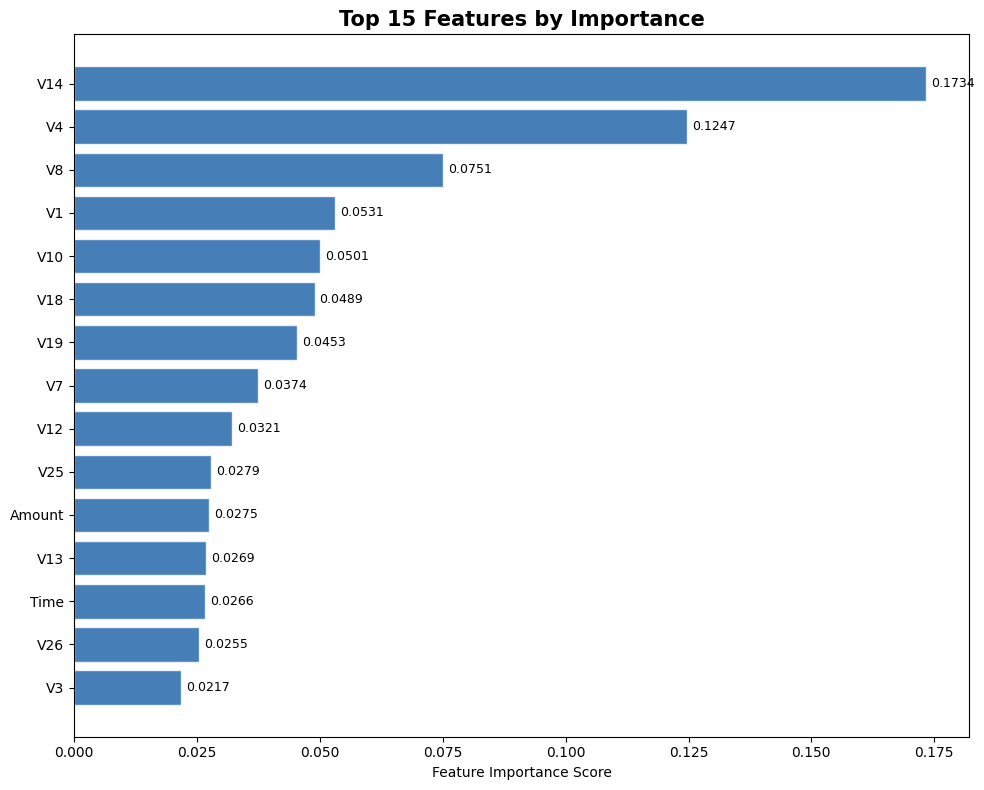


Top 5 most Important Features:
  V14        0.1734
  V4         0.1247
  V8         0.0751
  V1         0.0531
  V10        0.0501


In [11]:
xgb_model = xgb_pipeline.named_steps['model']
feature_names = X.columns.tolist()
importances = xgb_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending = True).tail(15)

fig, ax = plt.subplots(figsize = (10,8))
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'], color = '#185FA5', alpha = 0.8, edgecolor = 'white')
ax.set_title('Top 15 Features by Importance', fontweight = 'bold', fontsize = 15)
ax.set_xlabel('Feature Importance Score')

for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va = 'center', fontsize = 9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most Important Features:")
for _, row in feat_imp.tail(5).iloc[::-1].iterrows():
    print(f"  {row['Feature']:<10} {row['Importance']:.4f}")

Training ROC AUC: 1.0000
Validation ROC AUC: 0.9745
Gap: 0.0255
Good Fit (Balanced Model)


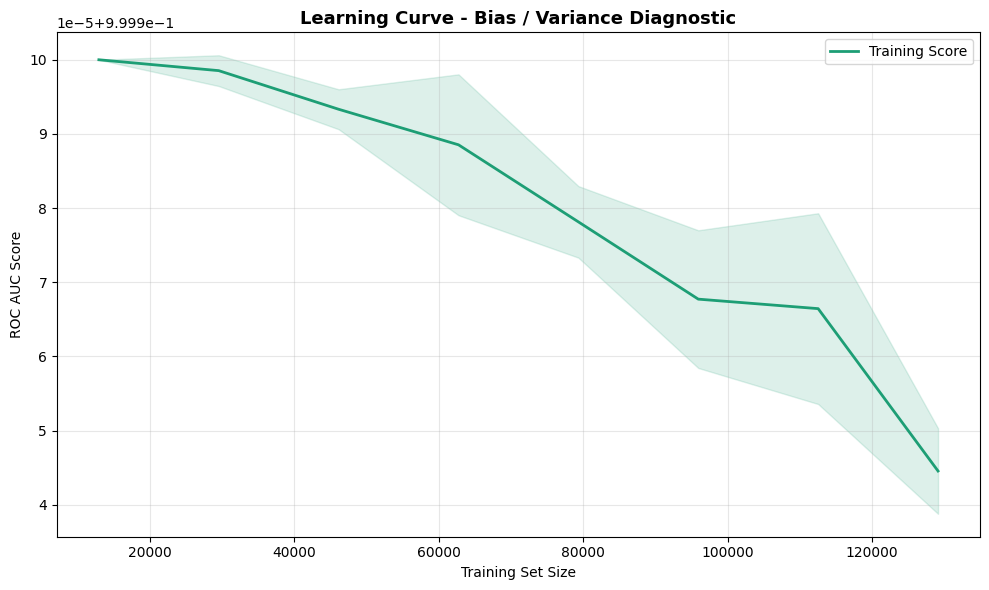

In [12]:
train_pred = xgb_pipeline.predict(X_train)
train_probs = xgb_pipeline.predict_proba(X_train)[:, 1]
train_roc = roc_auc_score(y_train, train_probs)

val_roc_final = roc_auc_score(y_val, val_probs)
print(f"Training ROC AUC: {train_roc:.4f}")
print(f"Validation ROC AUC: {val_roc_final:.4f}")
print(f"Gap: {train_roc - val_roc_final:.4f}")

gap = train_roc - val_roc_final
if gap > 0.05:
    print("High Variance (Overfitting)")
elif val_roc_final < 0.85:
    print("High Bias (Underfitting)")
else:
    print("Good Fit (Balanced Model)")

from sklearn.model_selection import learning_curve

simple_pipeline = Pipeline([
    ('scalar', StandardScaler()),
    ('model', XGBClassifier(n_estimators = 100, max_depth = 4,
                            learning_rate = 0.1, random_state = 42,
                            use_label_encoder = False, eval_metric = 'aucpr',
                            n_jobs = -1, scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()))
])

train_sizes, train_scores, val_scores = learning_curve(simple_pipeline, X_train, y_train, cv = 3, scoring = 'roc_auc', train_sizes = np.linspace(0.1, 1.0, 8), n_jobs = -1)

plt.figure(figsize = (10,6))
plt.plot(train_sizes, train_scores.mean(axis = 1), color = '#1D9E75', linewidth = 2, label = 'Training Score')
plt.fill_between(train_sizes, train_scores.mean(axis = 1) - train_scores.std(axis = 1),
                 train_scores.mean(axis = 1) + train_scores.std(axis = 1), alpha = 0.15, color = '#1D9E75')
plt.title('Learning Curve - Bias / Variance Diagnostic', fontsize = 13, fontweight = 'bold')
plt.xlabel('Training Set Size')
plt.ylabel('ROC AUC Score')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.savefig('Learning_curve.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [13]:
nn_scalar = StandardScaler()
X_train_scaled = nn_scalar.fit_transform(X_train)
X_val_scaled = nn_scalar.transform(X_val)
X_test_scaled = nn_scalar.transform(X_test)

smote = SMOTE(random_state = 42, sampling_strategy = 0.1)
X_train_nn, y_train_nn = smote.fit_resample(X_train_scaled, y_train)
print(f"After SMOTE - Training Samples: {len(X_train_nn):,}")
print(f"Fraud Samples: {y_train_nn.sum():,}")

nn_model = Sequential([
    Dense(256, activation = 'relu', input_shape = (X_train_nn.shape[1],)), BatchNormalization(), Dropout(0.3),
    Dense(128, activation = 'relu'), BatchNormalization(), Dropout(0.3),
    Dense(64, activation = 'relu'), Dropout(0.2),
    Dense(2, activation = 'softmax')
])

nn_model.compile(
    optimizer = Adam(learning_rate = 0.001), loss = 'sparse_categorical_crossentropy', metrics = ['accuracy']
)

nn_model.summary()

After SMOTE - Training Samples: 212,667
Fraud Samples: 19,333


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,754 (198.26 KB)

 Trainable params: 49,986 (195.26 KB)

 Non-trainable params: 768 (3.00 KB)

In [14]:
class_weights = compute_class_weight('balanced', classes = np.unique(y_train_nn), y = y_train_nn)
class_weight_dict = dict(enumerate(class_weights))
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights = True, verbose = 1)

history = nn_model.fit(
    X_train_nn, y_train_nn,
    validation_data = (X_val_scaled, y_val),
    epochs = 50, batch_size = 256, class_weight = class_weight_dict,
    callbacks = [early_stopping], verbose = 1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")

Epoch 1/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9743 - loss: 0.0662 - val_accuracy: 0.9913 - val_loss: 0.0258
Epoch 2/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9905 - loss: 0.0228 - val_accuracy: 0.9955 - val_loss: 0.0152
Epoch 3/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9939 - loss: 0.0152 - val_accuracy: 0.9950 - val_loss: 0.0177
Epoch 4/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9945 - loss: 0.0132 - val_accuracy: 0.9961 - val_loss: 0.0147
Epoch 5/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9955 - loss: 0.0112 - val_accuracy: 0.9964 - val_loss: 0.0152
Epoch 6/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9958 - loss: 0.0107 - val_accuracy: 0.9975 - val_loss: 0.0123
Epoch 7/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9969 - loss: 0.0085 - val_accuracy: 0.9974 - val_loss: 0.0138
Epoch 8/50
831/831 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9970 - loss: 0.0077 - val_accura

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

XGBoost Pipeline:
  Fraud caught (True Positives):       62
  Fraud missed (False Negatives):      12
  False alarms (False Positives):     148
  Fraud recall: 83.8%

Neural Network:
  Fraud caught (True Positives):       63
  Fraud missed (False Negatives):      11
  False alarms (False Positives):     103
  Fraud recall: 85.1%


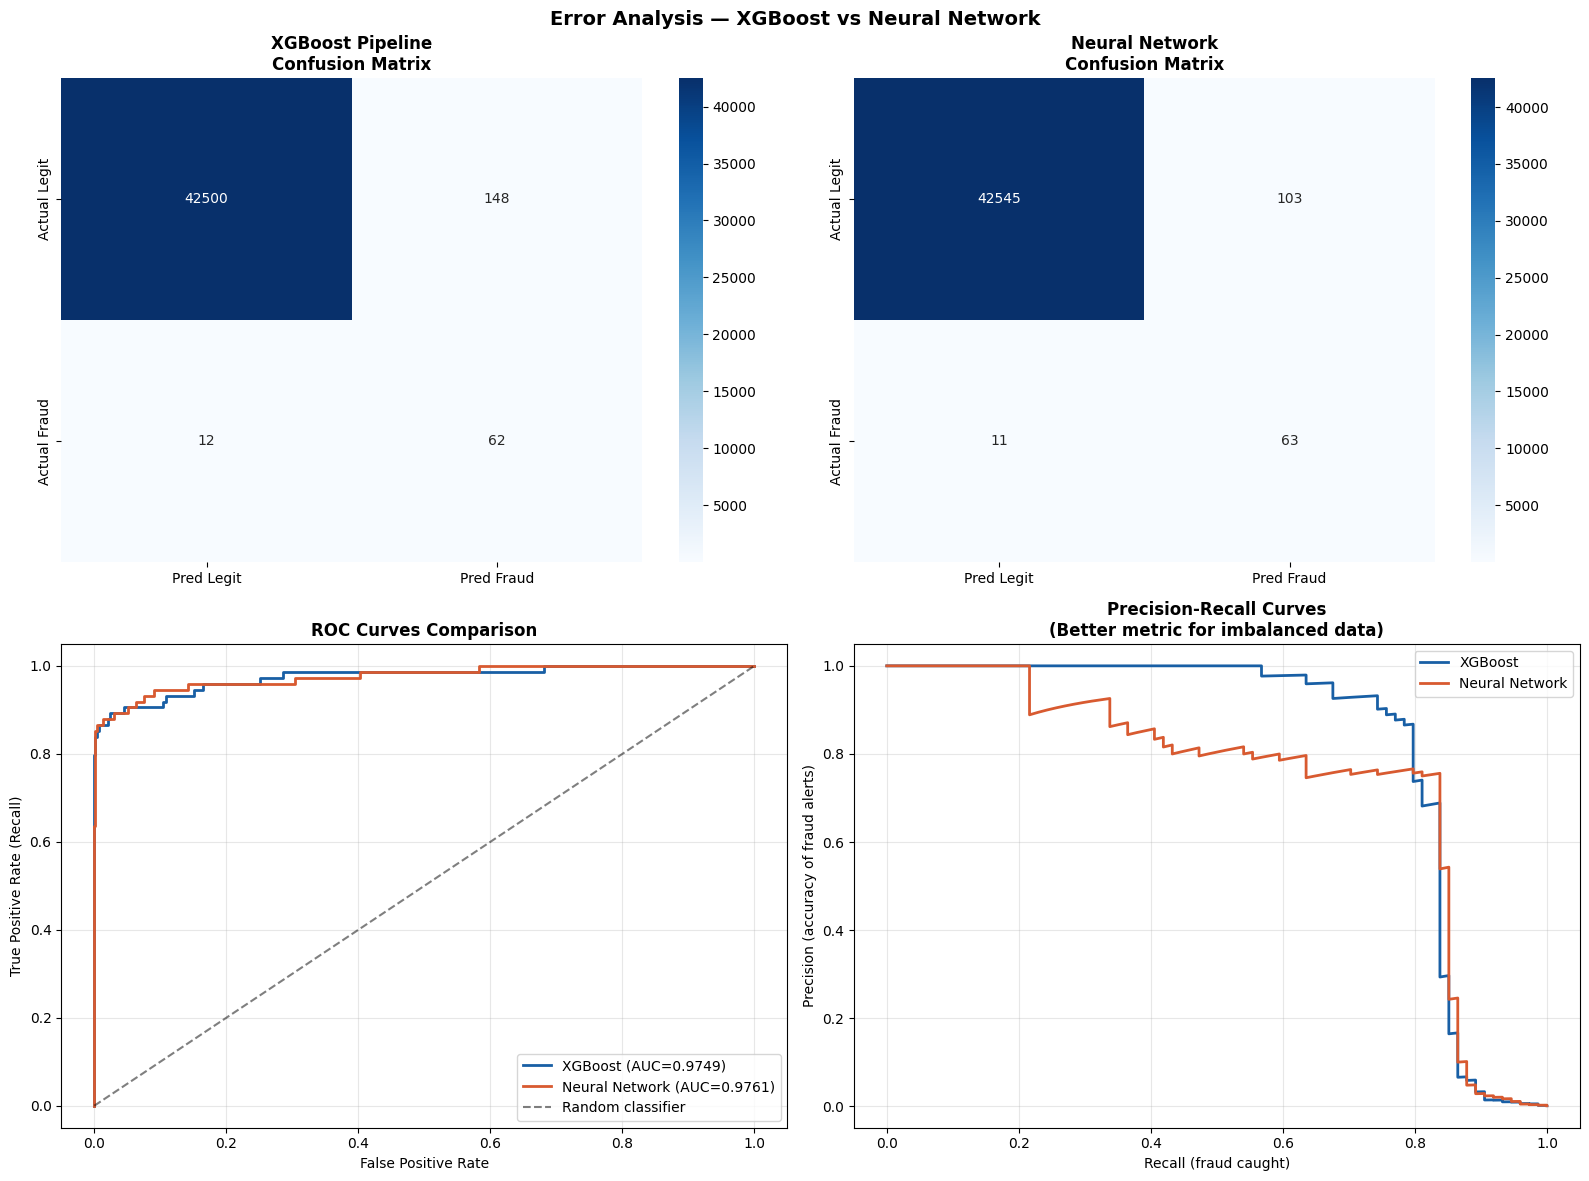

In [15]:
xgb_test_pred = xgb_pipeline.predict(X_test)
xgb_test_probs = xgb_pipeline.predict_proba(X_test)[:, 1]

nn_test_probs = nn_model.predict(X_test_scaled)[:, 1]
nn_test_pred = (nn_test_probs > 0.5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Error Analysis — XGBoost vs Neural Network',
             fontsize=14, fontweight='bold')

for idx, (name, pred, probs) in enumerate([
    ('XGBoost Pipeline', xgb_test_pred, xgb_test_probs),
    ('Neural Network', nn_test_pred, nn_test_probs)
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d',
                ax=axes[0, idx], cmap='Blues',
                xticklabels=['Pred Legit', 'Pred Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'])
    axes[0, idx].set_title(f'{name}\nConfusion Matrix',
                           fontweight='bold')

    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name}:")
    print(f"  Fraud caught (True Positives):    {tp:>5}")
    print(f"  Fraud missed (False Negatives):   {fn:>5}")
    print(f"  False alarms (False Positives):   {fp:>5}")
    print(f"  Fraud recall: {tp/(tp+fn)*100:.1f}%")

# ROC curves
for idx, (name, probs, color) in enumerate([
    ('XGBoost', xgb_test_probs, '#185FA5'),
    ('Neural Network', nn_test_probs, '#D85A30')
]):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[1, 0].plot(fpr, tpr, color=color, linewidth=2,
                    label=f'{name} (AUC={auc:.4f})')

axes[1, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5,
                label='Random classifier')
axes[1, 0].set_title('ROC Curves Comparison', fontweight='bold')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate (Recall)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

for name, probs, color in [
    ('XGBoost', xgb_test_probs, '#185FA5'),
    ('Neural Network', nn_test_probs, '#D85A30')
]:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    axes[1, 1].plot(recall, precision, color=color,
                    linewidth=2, label=name)

axes[1, 1].set_title('Precision-Recall Curves\n'
                      '(Better metric for imbalanced data)',
                      fontweight='bold')
axes[1, 1].set_xlabel('Recall (fraud caught)')
axes[1, 1].set_ylabel('Precision (accuracy of fraud alerts)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
xgb_roc = roc_auc_score(y_test, xgb_test_probs)
nn_roc = roc_auc_score(y_test, nn_test_probs)

xgb_cm = confusion_matrix(y_test, xgb_test_pred)
nn_cm = confusion_matrix(y_test, nn_test_pred)

_,_,xgb_fn, xgb_tp = xgb_cm.ravel()
_,_,nn_fn, nn_tp = nn_cm.ravel()

print(f"{'Metric':<30}{'XGBoost':>12}{'Neural_Net':>12}")
print(f"{'ROC AUC':<30} {xgb_roc:>12.4f} {nn_roc:>12.4f}")
print(f"{'Fraud Recall':<30}" f"{xgb_tp/(xgb_tp+xgb_fn)*100:>12.1f}%" f"{nn_tp/(nn_tp+nn_fn)*100:>12.1f}%")
print(f"{'Preprocessing': <30} {'Pipeline':>12} {'Manual':>12}")
print(f"{'Training Speed':<30} {'Faster':>12} {'Slower':>12}")
print(f"{'Interpretability':<30} {'Feature Importance':>12} {'Limited':>12}")

if xgb_roc > nn_roc:
    print(f"XGBoost ({xgb_roc:.4f})")
else:
    print(f"Neural Network ({nn_roc:.4f})")

print(f"\n📊 XGBoost DETAILED REPORT:")
print(classification_report(y_test, xgb_test_pred, target_names=['Legitimate', 'Fraud']))

print(f"\n📊 NEURAL NETWORK DETAILED REPORT:")
print(classification_report(y_test, nn_test_pred, target_names=['Legitimate', 'Fraud']))

print(f"\nKEY LEARNINGS:")
print(f"1. Pipeline ensures preprocessing never leaks between splits")
print(f"2. XGBoost with scale_pos_weight handles imbalance natively")
print(f"3. SMOTE creates synthetic fraud samples for better recall")
print(f"4. Early stopping prevented NN overfitting automatically")
print(f"5. ROC AUC is better than accuracy for imbalanced datasets")
print(f"6. Precision-Recall curve reveals the recall-precision tradeoff")
print(f"7. Feature importance shows V14, V17 are top fraud signals")

Metric                             XGBoost  Neural_Net
ROC AUC                              0.9749       0.9761
Fraud Recall                          83.8%        85.1%
Preprocessing                      Pipeline       Manual
Training Speed                       Faster       Slower
Interpretability               Feature Importance      Limited
Neural Network (0.9761)

📊 XGBoost DETAILED REPORT:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42648
       Fraud       0.30      0.84      0.44        74

    accuracy                           1.00     42722
   macro avg       0.65      0.92      0.72     42722
weighted avg       1.00      1.00      1.00     42722


📊 NEURAL NETWORK DETAILED REPORT:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42648
       Fraud       0.38      0.85      0.53        74

    accuracy                           1.00     42722
   macro avg       0.6